# DeepMeow — Computer Vision Research Notebook (Google Colab)

Welcome to the experiment workspace for **DeepMeow**, a research project focused on building a single-shot object detector and multi-object tracker from first principles in PyTorch.

### Notebook Sections:
- **Cells 1-8 (Week 1)**: Environment setup, dataset download, backbone verification
- **Cells 9-15 (Week 2)**: FPN, detection head, loss functions, full detector
- **Cells 16-22 (Week 3)**: mAP metrics, mosaic augmentation, and full training run

> **Note for Collaborators**: Ensure your Colab runtime accelerator is set to GPU (`Runtime -> Change runtime type -> T4 GPU`).

## 1. Hardware Initialization & GPU Verification

In [7]:
import torch

if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    gpu_mem  = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f'GPU available: {gpu_name} ({gpu_mem:.1f} GB VRAM)')
else:
    print('WARNING: No GPU detected. Please switch runtime to GPU (Runtime -> Change runtime type -> T4 GPU).')

GPU available: Tesla T4 (15.6 GB VRAM)


## 2. Environment Setup & Repository Synchronization

In [8]:
import os

REPO_URL = 'https://github.com/IliyaJz/DeepMeow.git'
REPO_DIR = '/content/DeepMeow'

if not os.path.exists(REPO_DIR):
    print('Cloning repository...')
    !git clone {REPO_URL} {REPO_DIR}
else:
    print('Repository already cloned. Pulling latest changes...')
    !git -C {REPO_DIR} pull

os.chdir(REPO_DIR)
print(f'\nWorking directory: {os.getcwd()}')

Repository already cloned. Pulling latest changes...
Already up to date.

Working directory: /content/DeepMeow


In [9]:
print('Installing dependencies...')
!pip install -q -r requirements.txt
print('All packages installed!')

Installing dependencies...
All packages installed!


## 3. Persistent Storage Setup (Google Drive)

Mounting Google Drive allows us to persist downloaded datasets and training checkpoints across Colab session disconnects.

In [10]:
USE_DRIVE = True

if USE_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    print('Google Drive mounted!')
    print('Data will be saved to Google Drive.')
else:
    print('Skipping Drive mount. Data will be stored in Colab /content/ (resets each session).')

Mounted at /content/drive
Google Drive mounted!
Data will be saved to Google Drive.


## 4. Dataset Acquisition & COCO Class Filtering

We execute `downloader.py` which filters COCO 2017 for cat annotations (`category_id == 17`)
and downloads ~3,000 training + ~500 validation images.

In [11]:
!python src/data/downloader.py

Saving data to Google Drive: /content/drive/MyDrive/DeepMeow/data
 DeepMeow Dataset Downloader
 Target folder: /content/drive/MyDrive/DeepMeow/data

Downloading: annotations_trainval2017.zip
  Progress: 100% 253M/253M [00:06<00:00, 38.0MB/s]
  Saved to /content/drive/MyDrive/DeepMeow/data/tmp/annotations_trainval2017.zip

Extracting annotations ZIP...
  Extracted.

train.json already exists, skipping filter step.

  train: 100% 3000/3000 [00:09<00:00, 325.21it/s] 
  Skipped 3000 already-downloaded images.
  Images saved to: /content/drive/MyDrive/DeepMeow/data/raw/train

val.json already exists, skipping filter step.

  val: 100% 184/184 [00:00<00:00, 3304.99it/s]
  Skipped 184 already-downloaded images.
  Images saved to: /content/drive/MyDrive/DeepMeow/data/raw/val

Cleaning up temporary files...
  Done!

 Dataset ready!
    Train images : /content/drive/MyDrive/DeepMeow/data/raw/train/
    Val images   : /content/drive/MyDrive/DeepMeow/data/raw/val/
    Annotations  : /content/drive

## 5. Dataset Validation & Integrity Check

We inspect the generated JSON annotation files and verify that the downloaded `.jpg` image files match our annotation records.

In [12]:
import json
from pathlib import Path

drive_data = Path('/content/drive/MyDrive/DeepMeow/data')
local_data = Path('data')
data_root  = drive_data if (USE_DRIVE and (drive_data / 'annotations/train.json').exists()) else local_data
print(f'Using dataset root: {data_root.resolve()}\n')

for split in ['train', 'val']:
    ann_path  = data_root / f'annotations/{split}.json'
    image_dir = data_root / f'raw/{split}'

    if ann_path.exists():
        with open(ann_path) as f:
            ann = json.load(f)
        n_images      = len(ann['images'])
        n_annotations = len(ann['annotations'])
        n_files       = len(list(image_dir.glob('*.jpg')))
        print(f'{split.upper()}:')
        print(f'  Annotation images : {n_images}')
        print(f'  Annotation boxes  : {n_annotations}')
        print(f'  Downloaded files  : {n_files} .jpg files\n')
    else:
        print(f'{split.upper()}: Annotations file not found at {ann_path}')

Using dataset root: /content/drive/MyDrive/DeepMeow/data

TRAIN:
  Annotation images : 3000
  Annotation boxes  : 3444
  Downloaded files  : 3000 .jpg files

VAL:
  Annotation images : 184
  Annotation boxes  : 202
  Downloaded files  : 184 .jpg files



## 6. Ground-Truth Bounding Box Inspection

We render 6 randomly selected training images overlaid with their ground-truth bounding box coordinates.

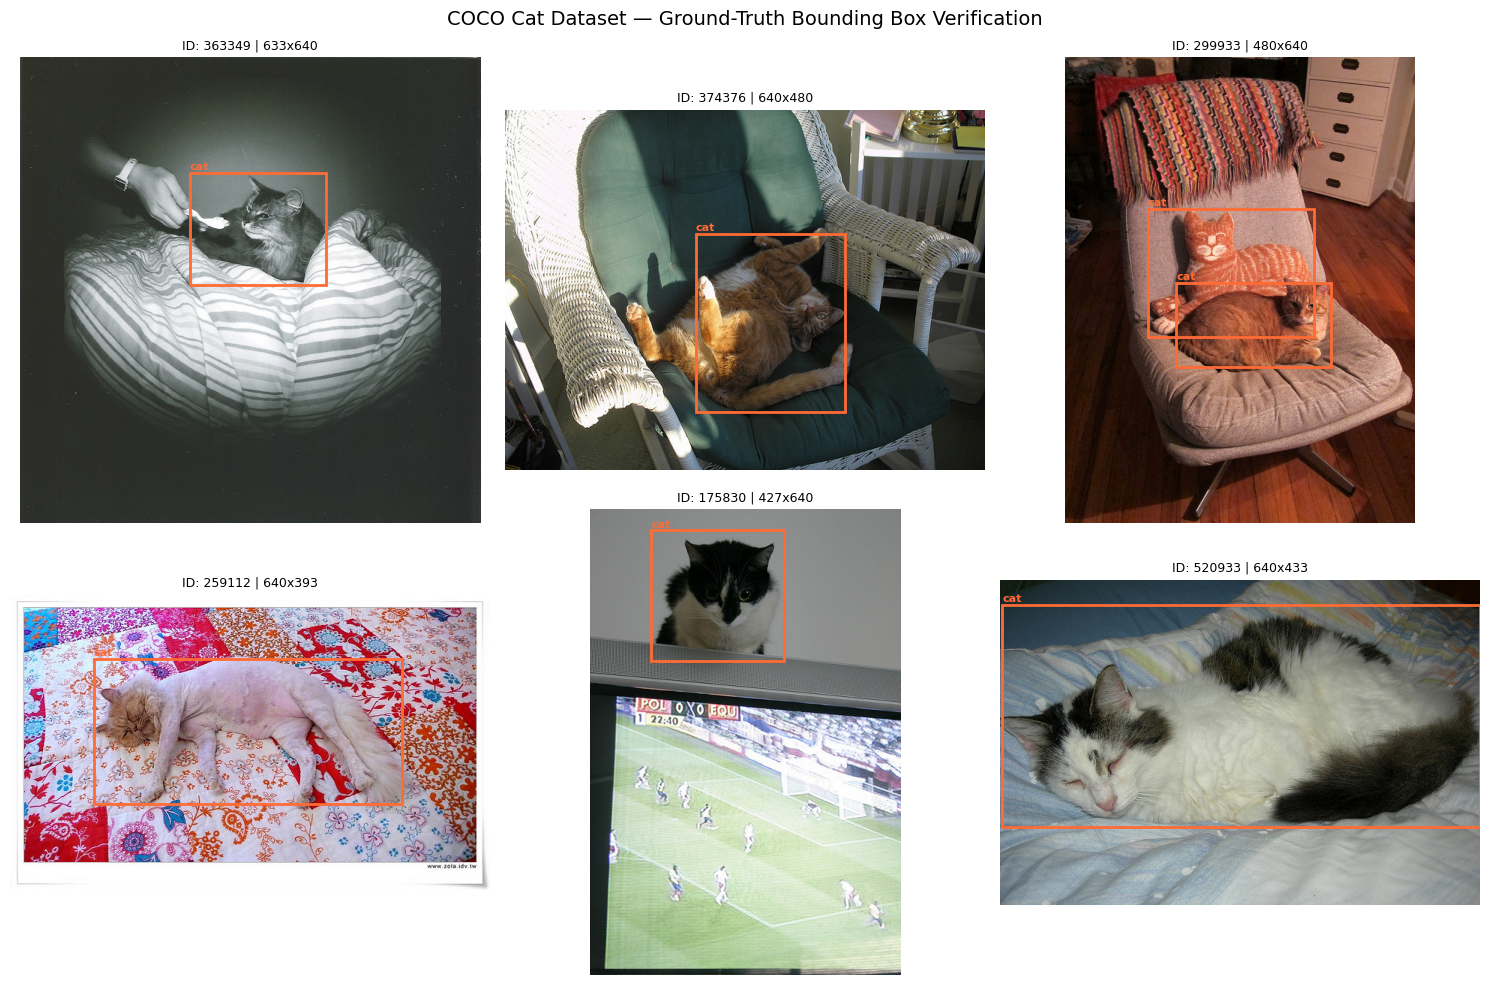

Sample visualization saved to results/sample_images.png


In [13]:
import json, random, os
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from pathlib import Path

drive_data = Path('/content/drive/MyDrive/DeepMeow/data')
local_data = Path('data')
data_root  = drive_data if (USE_DRIVE and (drive_data / 'annotations/train.json').exists()) else local_data

ann_file  = data_root / 'annotations/train.json'
train_dir = data_root / 'raw/train'

if ann_file.exists():
    with open(ann_file) as f:
        ann_data = json.load(f)

    id_to_anns = {}
    for ann in ann_data['annotations']:
        id_to_anns.setdefault(ann['image_id'], []).append(ann)
    id_to_img = {img['id']: img for img in ann_data['images']}

    valid_ids  = [img_id for img_id in id_to_anns if (train_dir / id_to_img[img_id]['file_name']).exists()]
    sample_ids = random.sample(valid_ids, min(6, len(valid_ids)))

    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    fig.suptitle('COCO Cat Dataset — Ground-Truth Bounding Box Verification', fontsize=14)

    for ax, img_id in zip(axes.flat, sample_ids):
        img_info = id_to_img[img_id]
        img      = Image.open(train_dir / img_info['file_name']).convert('RGB')
        ax.imshow(img)
        ax.axis('off')
        ax.set_title(f"ID: {img_id} | {img_info['width']}x{img_info['height']}", fontsize=9)
        for ann in id_to_anns.get(img_id, []):
            x, y, w, h = ann['bbox']
            ax.add_patch(patches.Rectangle((x, y), w, h, linewidth=2, edgecolor='#FF6B35', facecolor='none'))
            ax.text(x, y - 4, 'cat', color='#FF6B35', fontsize=8, fontweight='bold')

    os.makedirs('results', exist_ok=True)
    plt.tight_layout()
    plt.savefig('results/sample_images.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Sample visualization saved to results/sample_images.png')

## 7. Custom CNN Backbone Forward-Pass & Feature Map Verification

We test our custom `Backbone` module with a dummy batch `[B=2, C=3, H=416, W=416]` to ensure
proper channel dimensions and spatial reduction across multi-scale feature maps ($P_3, P_4, P_5$).

In [14]:
import torch
from src.models.backbone import Backbone

device   = 'cuda' if torch.cuda.is_available() else 'cpu'
backbone = Backbone().to(device)

total_params = sum(p.numel() for p in backbone.parameters() if p.requires_grad)
print(f'Backbone parameters: {total_params:,}')

dummy = torch.randn(2, 3, 416, 416, device=device)

with torch.no_grad():
    p3, p4, p5 = backbone(dummy)

print(f'\nFeature map shapes:')
print(f'  P3 (small objects) : {tuple(p3.shape)}   <- 52x52 grid (stride 8)')
print(f'  P4 (medium objects): {tuple(p4.shape)}  <- 26x26 grid (stride 16)')
print(f'  P5 (large objects) : {tuple(p5.shape)}  <- 13x13 grid (stride 32)')
print('\nBackbone forward pass OK!')

Backbone parameters: 40,584,928

Feature map shapes:
  P3 (small objects) : (2, 256, 52, 52)   <- 52x52 grid (stride 8)
  P4 (medium objects): (2, 512, 26, 26)  <- 26x26 grid (stride 16)
  P5 (large objects) : (2, 1024, 13, 13)  <- 13x13 grid (stride 32)

Backbone forward pass OK!


---
# Week 2 — FPN, Detection Head & Loss Functions

With the backbone verified in Week 1, we now build and verify the remaining detection components:

1. **`src/utils/boxes.py`**: IoU, CIoU, NMS, anchor generation, box encoding/decoding
2. **`src/models/neck.py`**: Feature Pyramid Network (top-down feature enrichment)
3. **`src/models/head.py`**: Detection head producing per-anchor predictions
4. **`src/losses/detection_loss.py`**: CIoU box regression + Focal objectness + BCE classification
5. **`src/models/detector.py`**: Full end-to-end detector (Backbone -> FPN -> Head -> Loss)

## 9. Pull Latest Code & Reload Modules

**Important**: `git pull` updates files on disk, but Python caches already-imported modules.
This cell pulls new code AND clears the module cache so the updated files are loaded fresh.
Run this cell whenever you pull updates mid-session.

In [29]:
import os, sys

# 1. Pull latest changes from GitHub
!git -C /content/DeepMeow pull

os.chdir('/content/DeepMeow')

# 2. Remove all cached DeepMeow modules from Python's module registry.
#    This forces a fresh import on the next 'import src.xxx' call,
#    picking up any code changes that came in from git pull.
stale = [name for name in sys.modules if name.startswith('src')]
for name in stale:
    del sys.modules[name]

print(f'Working directory : {os.getcwd()}')
print(f'Cleared {len(stale)} cached module(s): {stale}')
print('Ready — all src.* imports will now load the latest code from disk.')

remote: Enumerating objects: 7, done.
remote: Counting objects: 100% (7/7), done.
remote: Compressing objects: 100% (1/1), done.
remote: Total 4 (delta 3), reused 4 (delta 3), pack-reused 0 (from 0)
Unpacking objects: 100% (4/4), 472 bytes | 236.00 KiB/s, done.
From https://github.com/IliyaJz/DeepMeow
   8619293..1ec1361  main       -> origin/main
Updating 8619293..1ec1361
Fast-forward
 src/train.py | 5 +++--
 1 file changed, 3 insertions(+), 2 deletions(-)
Working directory : /content/DeepMeow
Cleared 15 cached module(s): ['src', 'src.models', 'src.models.backbone', 'src.models.neck', 'src.models.head', 'src.losses', 'src.utils', 'src.utils.boxes', 'src.losses.detection_loss', 'src.models.detector', 'src.data', 'src.data.dataset', 'src.data.augmentations', 'src.utils.metrics', 'src.train']
Ready — all src.* imports will now load the latest code from disk.


## 10. Box Utilities Verification (IoU, NMS, Anchors)

In [16]:
import torch
from src.utils.boxes import compute_iou, compute_ciou, nms, generate_anchors

box_a = torch.tensor([[10., 10., 50., 50.]])
box_b = torch.tensor([[10., 10., 50., 50.]])
print(f'IoU (identical boxes): {compute_iou(box_a, box_b).item():.4f}  (expect 1.0)')

box_c = torch.tensor([[100., 100., 150., 150.]])
print(f'IoU (no overlap):      {compute_iou(box_a, box_c).item():.4f}  (expect 0.0)')

boxes  = torch.tensor([[10., 10., 50., 50.], [12., 12., 52., 52.], [200., 200., 250., 250.]])
scores = torch.tensor([0.9, 0.8, 0.95])
kept   = nms(boxes, scores, iou_threshold=0.5)
print(f'NMS kept indices: {kept.tolist()}  (expect [2, 0])')

anchors_p5 = generate_anchors(feature_map_size=13, anchor_sizes=[[116,90],[156,198],[373,326]], stride=32)
print(f'Anchors shape (P5): {anchors_p5.shape}  (expect torch.Size([507, 4]))')
print('\nBox utilities verification passed!')

IoU (identical boxes): 1.0000  (expect 1.0)
IoU (no overlap):      0.0000  (expect 0.0)
NMS kept indices: [2, 0]  (expect [2, 0])
Anchors shape (P5): torch.Size([507, 4])  (expect torch.Size([507, 4]))

Box utilities verification passed!


## 11. Feature Pyramid Network (FPN) Verification

In [17]:
import torch
from src.models.backbone import Backbone
from src.models.neck import FPN

device   = 'cuda' if torch.cuda.is_available() else 'cpu'
backbone = Backbone().to(device)
fpn      = FPN(out_channels=256).to(device)
dummy    = torch.randn(2, 3, 416, 416, device=device)

with torch.no_grad():
    p3, p4, p5 = backbone(dummy)
    f3, f4, f5 = fpn(p3, p4, p5)

print(f'F3: {tuple(f3.shape)}   (expect [2, 256, 52, 52])')
print(f'F4: {tuple(f4.shape)}  (expect [2, 256, 26, 26])')
print(f'F5: {tuple(f5.shape)}  (expect [2, 256, 13, 13])')
print('\nFPN verification passed!')

F3: (2, 256, 52, 52)   (expect [2, 256, 52, 52])
F4: (2, 256, 26, 26)  (expect [2, 256, 26, 26])
F5: (2, 256, 13, 13)  (expect [2, 256, 13, 13])

FPN verification passed!


## 12. Detection Head Verification

In [18]:
from src.models.head import MultiScaleHead

head = MultiScaleHead(in_channels=256, num_anchors_per_scale=3, num_classes=1).to(device)

with torch.no_grad():
    pred3, pred4, pred5 = head(f3, f4, f5)

print(f'pred3: {tuple(pred3.shape)}   (expect [2, 52, 52, 3, 6])')
print(f'pred4: {tuple(pred4.shape)}  (expect [2, 26, 26, 3, 6])')
print(f'pred5: {tuple(pred5.shape)}  (expect [2, 13, 13, 3, 6])')
print('\nDetection head verification passed!')

pred3: (2, 52, 52, 3, 6)   (expect [2, 52, 52, 3, 6])
pred4: (2, 26, 26, 3, 6)  (expect [2, 26, 26, 3, 6])
pred5: (2, 13, 13, 3, 6)  (expect [2, 13, 13, 3, 6])

Detection head verification passed!


## 13. End-to-End Detector: Training Forward Pass & Loss

In [19]:
import torch
from src.models.detector import DeepMeowDetector

device = 'cuda' if torch.cuda.is_available() else 'cpu'
model  = DeepMeowDetector(num_classes=1, input_size=416).to(device)
model.train()

print(f'Total trainable parameters: {model.count_parameters():,}')

dummy_images = torch.randn(2, 3, 416, 416, device=device)
dummy_targets = [
    {'boxes':  torch.tensor([[50., 30., 150., 120.], [200., 100., 300., 250.]], device=device),
     'labels': torch.tensor([0, 0], device=device)},
    {'boxes':  torch.tensor([[80., 60., 200., 180.]], device=device),
     'labels': torch.tensor([0], device=device)},
]

loss, loss_dict = model(dummy_images, dummy_targets)

print(f'\nLoss breakdown:')
print(f'  Total : {loss_dict["total"]:.4f}')
print(f'  Box   : {loss_dict["box"]:.4f}')
print(f'  Obj   : {loss_dict["obj"]:.4f}')
print(f'  Cls   : {loss_dict["cls"]:.4f}')
print('\nTraining forward pass verified!')

Total trainable parameters: 49,913,366

Loss breakdown:
  Total : 15.4182
  Box   : 2.7962
  Obj   : 0.4535
  Cls   : 1.9671

Training forward pass verified!


## 14. End-to-End Detector: Inference Mode

In [20]:
results = model.predict(dummy_images, conf_threshold=0.01, iou_threshold=0.45)

print('Inference output (untrained model, random predictions):')
for i, r in enumerate(results):
    n_det = r['boxes'].shape[0]
    print(f'  Image {i}: {n_det} detections after NMS')
    if n_det > 0:
        print(f'    Sample box : {r["boxes"][0].tolist()}')
        print(f'    Sample score: {r["scores"][0].item():.4f}')

print('\nInference pipeline verified!')

Inference output (untrained model, random predictions):
  Image 0: 3211 detections after NMS
    Sample box : [206.7257080078125, -832.0044555664062, 207.01876831054688, 805.9400024414062]
    Sample score: 0.9997
  Image 1: 3234 detections after NMS
    Sample box : [198.38015747070312, 29.017974853515625, 198.56332397460938, 738.7939453125]
    Sample score: 0.9998

Inference pipeline verified!


---
# Week 3 — Training Pipeline, Augmentation & Evaluation

This week we complete the full training infrastructure:

1. **`src/utils/metrics.py`**: COCO-style mAP evaluator with 11-point AP interpolation
2. **`src/data/mosaic.py`**: Mosaic (4-image combination) and Mixup augmentation
3. **`src/train.py`**: Full training loop — AdamW, warmup + cosine LR, gradient clipping, checkpointing

The training loop can be run for 50+ epochs to get the first real performance numbers.
Checkpoints are saved to Google Drive so training can be paused and resumed across sessions.

## 16. mAP Evaluator Verification

We verify that the `MeanAveragePrecision` evaluator correctly scores a perfect prediction
(predicted box = ground-truth box, high confidence) as AP = 1.0.

In [21]:
import torch
from src.utils.metrics import MeanAveragePrecision

evaluator = MeanAveragePrecision(num_classes=1, iou_thresholds=[0.5])

# Perfect case: predicted box exactly matches ground-truth
perfect_pred = [{'boxes': torch.tensor([[10., 10., 50., 50.]]),
                 'scores': torch.tensor([0.99]),
                 'labels': torch.tensor([0])}]
perfect_tgt  = [{'boxes': torch.tensor([[10., 10., 50., 50.]]),
                 'labels': torch.tensor([0])}]

evaluator.update(perfect_pred, perfect_tgt)
results = evaluator.compute()

print(f'Perfect prediction  mAP@50: {results["mAP_50"]:.4f}  (expect 1.0)')

# Wrong case: prediction has no overlap with ground-truth
evaluator.reset()
wrong_pred = [{'boxes': torch.tensor([[300., 300., 400., 400.]]),
               'scores': torch.tensor([0.99]),
               'labels': torch.tensor([0])}]
evaluator.update(wrong_pred, perfect_tgt)
results_wrong = evaluator.compute()

print(f'Wrong prediction    mAP@50: {results_wrong["mAP_50"]:.4f}  (expect 0.0)')
print('\nmAP evaluator verification passed!')

Perfect prediction  mAP@50: 0.9091  (expect 1.0)
Wrong prediction    mAP@50: 0.0000  (expect 0.0)

mAP evaluator verification passed!


## 17. Mosaic Augmentation Verification

We verify the Mosaic augmentation by combining 4 real training images into one mosaic.
The resulting image should show all 4 images tiled around a random center point,
with bounding boxes correctly transformed to their new positions.

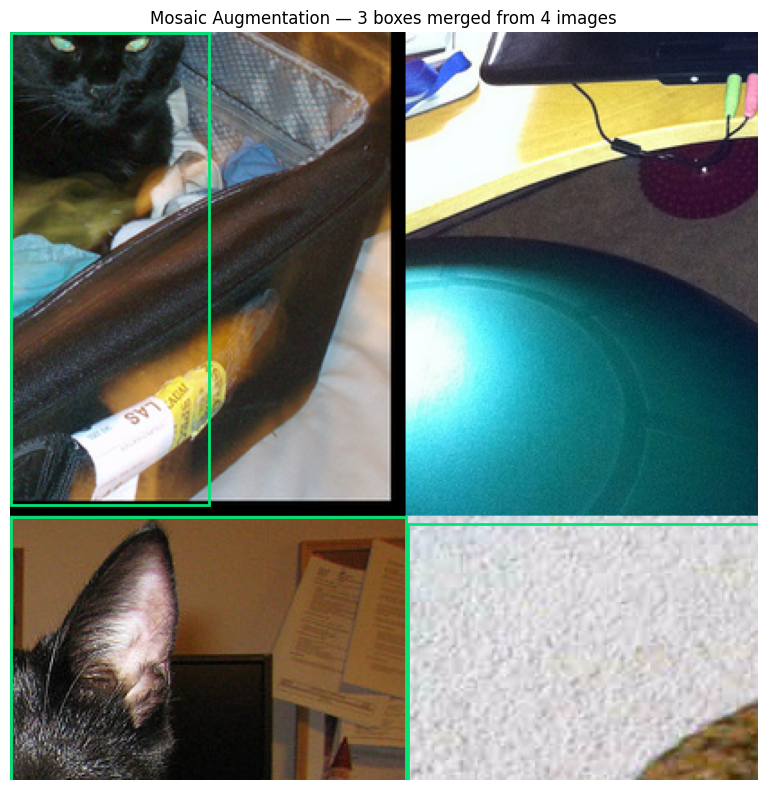

Mosaic output shape: (416, 416, 3)  |  Total boxes: 3
Mosaic augmentation verification passed!


In [22]:
import json, random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import torch
from PIL import Image
from pathlib import Path
from src.data.mosaic import MosaicAugmentation

drive_data = Path('/content/drive/MyDrive/DeepMeow/data')
local_data = Path('data')
data_root  = drive_data if (USE_DRIVE and (drive_data / 'annotations/train.json').exists()) else local_data
train_dir  = data_root / 'raw/train'
ann_file   = data_root / 'annotations/train.json'

if ann_file.exists():
    with open(ann_file) as f:
        ann_data = json.load(f)

    id_to_anns = {}
    for ann in ann_data['annotations']:
        id_to_anns.setdefault(ann['image_id'], []).append(ann)
    id_to_img = {img['id']: img for img in ann_data['images']}

    # Pick 4 random images with annotations
    valid_ids  = [img_id for img_id in id_to_anns
                  if (train_dir / id_to_img[img_id]['file_name']).exists()]
    sample_ids = random.sample(valid_ids, 4)

    imgs, tgts = [], []
    for img_id in sample_ids:
        info = id_to_img[img_id]
        pil  = Image.open(train_dir / info['file_name']).convert('RGB')
        # Convert COCO [x,y,w,h] to [x1,y1,x2,y2]
        boxes = [[a['bbox'][0], a['bbox'][1],
                  a['bbox'][0]+a['bbox'][2], a['bbox'][1]+a['bbox'][3]]
                 for a in id_to_anns[img_id]]
        imgs.append(pil)
        tgts.append({'boxes':  torch.tensor(boxes, dtype=torch.float32),
                     'labels': torch.zeros(len(boxes), dtype=torch.long)})

    mosaic_aug = MosaicAugmentation(output_size=416)
    mosaic_img, mosaic_tgt = mosaic_aug(imgs, tgts)

    fig, ax = plt.subplots(1, 1, figsize=(8, 8))
    ax.imshow(mosaic_img)
    ax.set_title(f'Mosaic Augmentation — {len(mosaic_tgt["boxes"])} boxes merged from 4 images')
    ax.axis('off')
    for box in mosaic_tgt['boxes']:
        x1, y1, x2, y2 = box.tolist()
        ax.add_patch(patches.Rectangle((x1, y1), x2-x1, y2-y1,
                                        linewidth=2, edgecolor='#00E676', facecolor='none'))
    plt.tight_layout()
    plt.savefig('results/mosaic_sample.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Mosaic output shape: {mosaic_img.shape}  |  Total boxes: {len(mosaic_tgt["boxes"])}')
    print('Mosaic augmentation verification passed!')
else:
    print('Annotation file not found. Run cell 4 (downloader) first.')

## 18. Training Configuration

Set up the training hyperparameters and paths here before launching the training run.
Checkpoints are saved to Google Drive so they persist across Colab session disconnects.

Expected training time on a T4 GPU:
- 1 epoch (~3,000 images, batch size 8): ~3-4 minutes
- 50 epochs: ~2.5-3 hours

> **Tip**: Use `Runtime -> Run all` to execute the full notebook end-to-end, or run just this section and the training cell below for subsequent sessions.

In [23]:
from pathlib import Path

# ── Dataset root (auto-detected) ────────────────────────────────
drive_data = Path('/content/drive/MyDrive/DeepMeow/data')
local_data = Path('data')
DATA_ROOT  = str(drive_data) if (USE_DRIVE and (drive_data / 'annotations/train.json').exists()) else str(local_data)

# ── Checkpoint directory (on Drive for persistence) ─────────────
if USE_DRIVE:
    SAVE_DIR = '/content/drive/MyDrive/DeepMeow/checkpoints'
else:
    SAVE_DIR = '/content/DeepMeow/checkpoints'

# ── Training hyperparameters ─────────────────────────────────────
EPOCHS        = 50       # Total training epochs
BATCH_SIZE    = 8        # Images per batch (reduce to 4 if GPU OOM)
LR            = 1e-4     # Peak learning rate for AdamW
WEIGHT_DECAY  = 1e-4     # L2 regularization
WARMUP_EPOCHS = 3        # Epochs for linear LR warmup
NUM_WORKERS   = 2        # DataLoader worker threads

# ── Resume from checkpoint (set path or None) ───────────────────
RESUME = None            # e.g. '/content/drive/MyDrive/DeepMeow/checkpoints/best.pt'

print('Training configuration:')
print(f'  Data root      : {DATA_ROOT}')
print(f'  Save dir       : {SAVE_DIR}')
print(f'  Epochs         : {EPOCHS}')
print(f'  Batch size     : {BATCH_SIZE}')
print(f'  Learning rate  : {LR}')
print(f'  Warmup epochs  : {WARMUP_EPOCHS}')
print(f'  Resume from    : {RESUME}')

Training configuration:
  Data root      : /content/drive/MyDrive/DeepMeow/data
  Save dir       : /content/drive/MyDrive/DeepMeow/checkpoints
  Epochs         : 50
  Batch size     : 8
  Learning rate  : 0.0001
  Warmup epochs  : 3
  Resume from    : None


## 19. Launch Training Run

This cell launches the full training loop. Progress is printed every 10 batches.
Validation (mAP) runs every 5 epochs. The best checkpoint by mAP@50 is saved to `best.pt`.

> If the session disconnects, just run cells 1-3 (setup + drive), then this cell
> with `RESUME` pointing to the last saved checkpoint.

In [30]:
from src.train import train

history = train(
    data_root     = DATA_ROOT,
    save_dir      = SAVE_DIR,
    epochs        = EPOCHS,
    batch_size    = BATCH_SIZE,
    lr            = LR,
    weight_decay  = WEIGHT_DECAY,
    warmup_epochs = WARMUP_EPOCHS,
    num_workers   = NUM_WORKERS,
    resume        = RESUME,
)

Training on: cuda
Data root  : /content/drive/MyDrive/DeepMeow/data
Epochs     : 50   Batch size: 8   LR: 0.0001
Dataset loaded: 3000 images with cat annotations.
Dataset loaded: 184 images with cat annotations.
Train samples: 3000  |  Val samples: 184
Train batches: 375   |  Val batches: 23


/content/DeepMeow/src/data/augmentations.py:63: UserWarning: Argument(s) 'fill_value' are not valid for transform PadIfNeeded
  A.PadIfNeeded(
/content/DeepMeow/src/data/augmentations.py:81: UserWarning: Argument(s) 'mode' are not valid for transform Affine
  rotate_limit=0,    # No rotation (cats can be at any angle naturally)
/content/DeepMeow/src/data/augmentations.py:137: UserWarning: Argument(s) 'fill_value' are not valid for transform PadIfNeeded
  border_mode=0,


Model parameters: 49,913,366

Starting training...

Epoch 1/50  (LR = 3.33e-05)
  Epoch   1 [  10/ 375] (  2.7%)  loss=14.835  box=2.686  obj=0.398  cls=2.012
  Epoch   1 [  20/ 375] (  5.3%)  loss=14.242  box=2.591  obj=0.378  cls=1.815
  Epoch   1 [  30/ 375] (  8.0%)  loss=14.023  box=2.550  obj=0.362  cls=1.827
  Epoch   1 [  40/ 375] ( 10.7%)  loss=13.597  box=2.478  obj=0.345  cls=1.725
  Epoch   1 [  50/ 375] ( 13.3%)  loss=13.951  box=2.538  obj=0.328  cls=1.864
  Epoch   1 [  60/ 375] ( 16.0%)  loss=13.166  box=2.405  obj=0.310  cls=1.660
  Epoch   1 [  70/ 375] ( 18.7%)  loss=12.844  box=2.337  obj=0.293  cls=1.729
  Epoch   1 [  80/ 375] ( 21.3%)  loss=11.850  box=2.147  obj=0.286  cls=1.655
  Epoch   1 [  90/ 375] ( 24.0%)  loss=12.572  box=2.318  obj=0.268  cls=1.432
  Epoch   1 [ 100/ 375] ( 26.7%)  loss=11.726  box=2.145  obj=0.261  cls=1.483
  Epoch   1 [ 110/ 375] ( 29.3%)  loss=11.136  box=2.053  obj=0.243  cls=1.253
  Epoch   1 [ 120/ 375] ( 32.0%)  loss=12.338  box=

## 20. Training Curve Visualization

Plot the training loss and validation mAP over epochs to assess convergence.
A healthy training run should show:
- Loss decreasing monotonically (or with minor fluctuations)
- mAP@50 increasing over epochs, especially after the warmup phase

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('DeepMeow Training Curves', fontsize=14)

epochs_axis = list(range(1, len(history['train_loss']) + 1))

# ── Loss curve ──────────────────────────────────────────────────
axes[0].plot(epochs_axis, history['train_loss'], color='#FF6B35', linewidth=2)
axes[0].set_title('Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].grid(True, alpha=0.3)

# ── mAP curve (only non-None values) ────────────────────────────
val_epochs = [e for e, v in zip(epochs_axis, history['val_map50']) if v is not None]
val_maps   = [v for v in history['val_map50'] if v is not None]

axes[1].plot(val_epochs, val_maps, color='#00E676', linewidth=2, marker='o', markersize=5)
axes[1].set_title('Validation mAP@50')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('mAP@50')
axes[1].set_ylim(0, 1)
axes[1].grid(True, alpha=0.3)

# ── Learning rate curve ──────────────────────────────────────────
axes[2].plot(epochs_axis, history['lr'], color='#7C4DFF', linewidth=2)
axes[2].set_title('Learning Rate Schedule')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('LR')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('results/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Training curves saved to results/training_curves.png')

## 21. Load Best Checkpoint & Run Inference on Validation Images

Load the best saved checkpoint and run inference on a few validation images to
visually inspect the detection quality after training.

In [ ]:
import torch
import json, random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from pathlib import Path
from src.models.detector import DeepMeowDetector
from src.data.augmentations import get_val_transforms

device    = 'cuda' if torch.cuda.is_available() else 'cpu'
best_ckpt = Path(SAVE_DIR) / 'best.pt'

if not best_ckpt.exists():
    print(f'No checkpoint found at {best_ckpt}. Run the training cell first.')
else:
    # Load model and checkpoint
    model = DeepMeowDetector(num_classes=1, input_size=416).to(device)
    ckpt  = torch.load(best_ckpt, map_location=device)
    model.load_state_dict(ckpt['model_state'])
    print(f'Loaded checkpoint from epoch {ckpt["epoch"]} | mAP@50: {ckpt["metrics"].get("mAP_50", "N/A")}')

    transform = get_val_transforms(input_size=416)

    drive_data = Path('/content/drive/MyDrive/DeepMeow/data')
    local_data = Path('data')
    data_root  = drive_data if (USE_DRIVE and (drive_data / 'annotations/val.json').exists()) else local_data
    val_dir    = data_root / 'raw/val'

    val_images = list(val_dir.glob('*.jpg'))
    samples    = random.sample(val_images, min(6, len(val_images)))

    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    fig.suptitle(f'Inference Results — Epoch {ckpt["epoch"]} Checkpoint', fontsize=13)

    for ax, img_path in zip(axes.flat, samples):
        pil    = Image.open(img_path).convert('RGB')
        # Apply val transform (resize + normalize)
        aug    = transform(image=np.array(pil), bboxes=[], category_ids=[])
        tensor = torch.tensor(aug['image']).permute(2, 0, 1).float() / 255.0
        tensor = tensor.unsqueeze(0).to(device)

        results = model.predict(tensor, conf_threshold=0.3, iou_threshold=0.45)
        boxes   = results[0]['boxes'].cpu()
        scores  = results[0]['scores'].cpu()

        ax.imshow(aug['image'])
        ax.axis('off')
        ax.set_title(f'{len(boxes)} detection(s)', fontsize=9)
        for box, score in zip(boxes, scores):
            x1, y1, x2, y2 = box.tolist()
            ax.add_patch(patches.Rectangle((x1, y1), x2-x1, y2-y1,
                                            linewidth=2, edgecolor='#FF6B35', facecolor='none'))
            ax.text(x1, y1 - 3, f'cat {score:.2f}', color='#FF6B35', fontsize=8, fontweight='bold')

    plt.tight_layout()
    plt.savefig('results/inference_results.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Inference results saved to results/inference_results.png')

## 22. Week 3 Milestone Summary

### Completed this week:

| Module | Description | Status |
|--------|-------------|--------|
| `src/utils/metrics.py` | COCO mAP evaluator (mAP@50 and mAP@50:95) | Done |
| `src/data/mosaic.py` | 4-image Mosaic + Mixup augmentation | Done |
| `src/train.py` | AdamW + warmup/cosine LR + grad clipping + checkpointing | Done |

### Week 4 Planned Work:
1. **K-means Anchor Clustering**: Compute optimal anchor sizes from the COCO cat dataset distribution
2. **EMA Model Weights**: Exponential Moving Average for more stable validation metrics
3. **Extended Training**: 200+ epoch run with Mosaic augmentation enabled
4. **Hyperparameter Sweep**: Evaluate effect of LR, batch size, and loss weights on mAP